In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\KPMG sem3\Time Series\Time-Series-Dataset.csv')

In [3]:
df.head(10)

,Date,Company,Open,High,Low,Close,Volume
0,2016-01-01,HCLTech,1545.39,1552.22,1536.89,1550.00,1956151
1,2016-01-01,Infosys,1842.72,1860.80,1828.59,1850.00,3706077
2,2016-01-01,TCS,3606.28,3622.06,3567.02,3600.00,1622560
3,2016-01-01,Wipro,701.00,704.40,697.61,700.00,3072354
4,2016-01-04,HCLTech,1566.69,1576.56,1550.24,1567.92,2207225
5,2016-01-04,Infosys,1838.12,1850.08,1817.29,1835.26,2548473
6,2016-01-04,TCS,3571.63,3592.16,3561.08,3568.83,1721751
7,2016-01-04,Wipro,683.51,687.93,675.58,683.73,3580823
8,2016-01-05,HCLTech,1574.81,1584.95,1566.81,1571.18,3844036
9,2016-01-05,Infosys,1815.43,1825.25,1778.32,1796.08,3482771


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     10000 non-null  object 
 1   Company  10000 non-null  object 
 2   Open     10000 non-null  float64
 3   High     10000 non-null  float64
 4   Low      10000 non-null  float64
 5   Close    10000 non-null  float64
 6   Volume   10000 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 547.0+ KB


In [5]:
df['Date']= pd.to_datetime(df['Date'])

In [6]:
df.dtypes

Date       datetime64[ns]
Company            object
Open              float64
High              float64
Low               float64
Close             float64
Volume              int64
dtype: object

In [7]:
df = df.sort_values('Date').copy()
df.set_index('Date', inplace=True)
df.head()

,Company,Open,High,Low,Close,Volume
Date,,,,,,
2016-01-01,HCLTech,1545.39,1552.22,1536.89,1550.00,1956151
2016-01-01,Infosys,1842.72,1860.80,1828.59,1850.00,3706077
2016-01-01,TCS,3606.28,3622.06,3567.02,3600.00,1622560
2016-01-01,Wipro,701.00,704.40,697.61,700.00,3072354
2016-01-04,HCLTech,1566.69,1576.56,1550.24,1567.92,2207225


In [8]:
df.isnull().sum()

Company    0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# which company has highest average closing price

Company    0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64

Company count:
Company
HCLTech    2500
Infosys    2500
TCS        2500
Wipro      2500
Name: count, dtype: int64

Close price summary by company:
                 mean           std      min       max
Company                                               
HCLTech  10695.276284  10838.399410  1501.06  41805.20
Infosys   3686.948628   1849.970799  1565.36   8731.91
TCS       5621.397644   1055.223060  3506.06   7996.09
Wipro      491.327928    156.786237   228.48    826.89


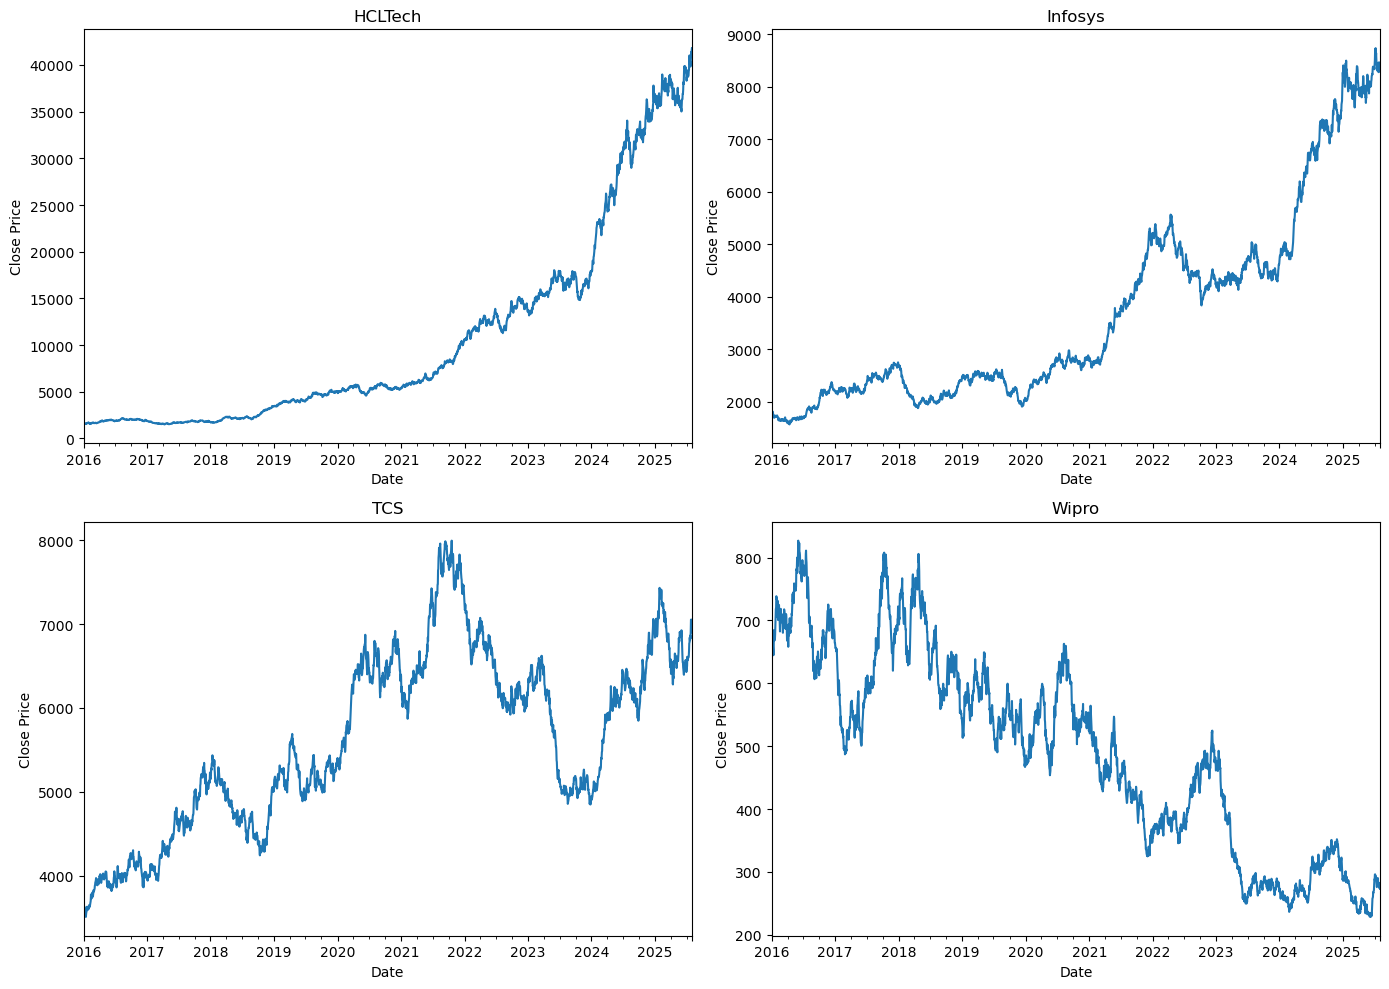

In [10]:
import matplotlib.pyplot as plt

# Check for missing values
print(df.isna().sum())
print('\nCompany count:')
print(df['Company'].value_counts())

# Summary statistics by company
summary = df.groupby('Company')['Close'].agg(['mean', 'std', 'min', 'max'])
print('\nClose price summary by company:')
print(summary)

# Visualize closing prices for each company over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (company, group) in zip(axes, df.groupby('Company')):
    group['Close'].plot(ax=ax, title=company)
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')

for ax in axes[len(df['Company'].unique()):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

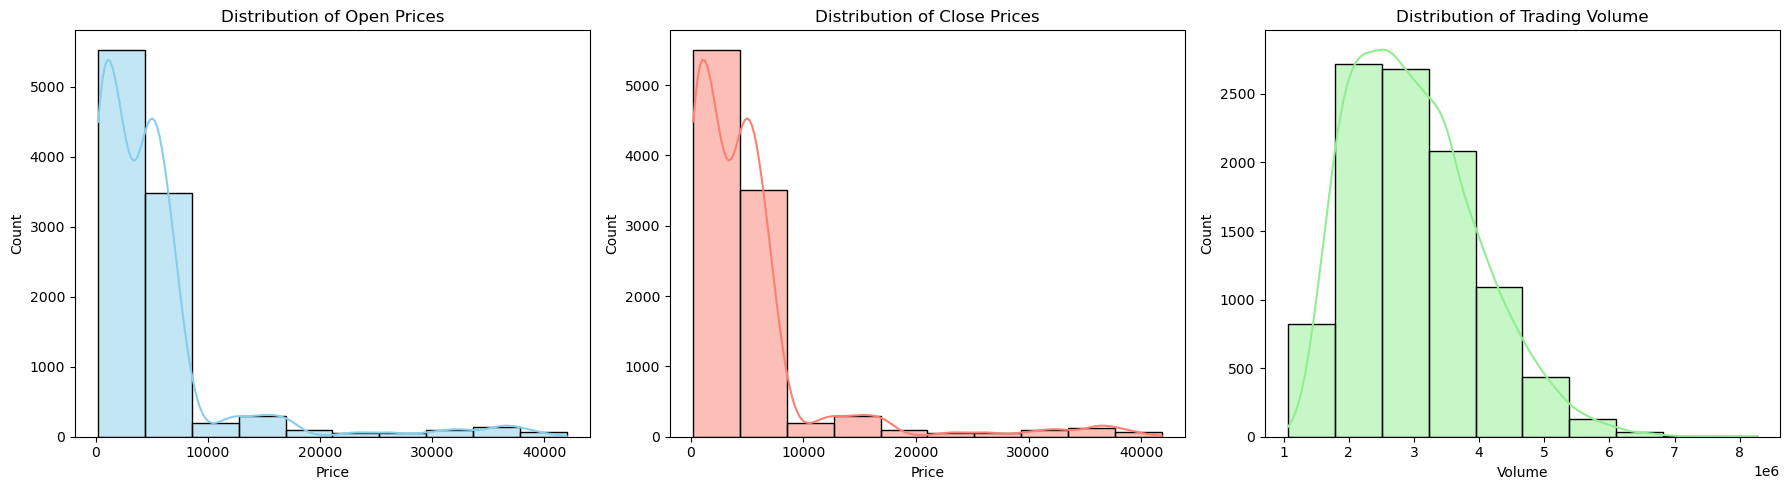

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting area (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram for Open Price
sns.histplot(data=df, x='Open', bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Open Prices')
axes[0].set_xlabel('Price')

# 2. Histogram for Close Price
sns.histplot(data=df, x='Close', bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Close Prices')
axes[1].set_xlabel('Price')

# 3. Histogram for Volume
sns.histplot(data=df, x='Volume', bins=10, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Trading Volume')
axes[2].set_xlabel('Volume')

plt.tight_layout()
plt.show()


# which  company is hghest volatile
* Hcl tech (Light blue ): shows highest volatile and overall highest price rangethe median sits around 8000, but it has massive upper wisker sketch past 30,000.

* infosys(pink): Display very stable low price range with few outlier

* TCS(Blue):  shows tightly bound distribustion highly consisitent around 6000.

Wipro(Purple): stock price is sighly lower

C:\Users\HP\AppData\Local\Temp\ipykernel_1964\3907546605.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Company', y='Close', ax=axes[0], palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_1964\3907546605.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Company', y='Volume', ax=axes[1], palette='Set2')


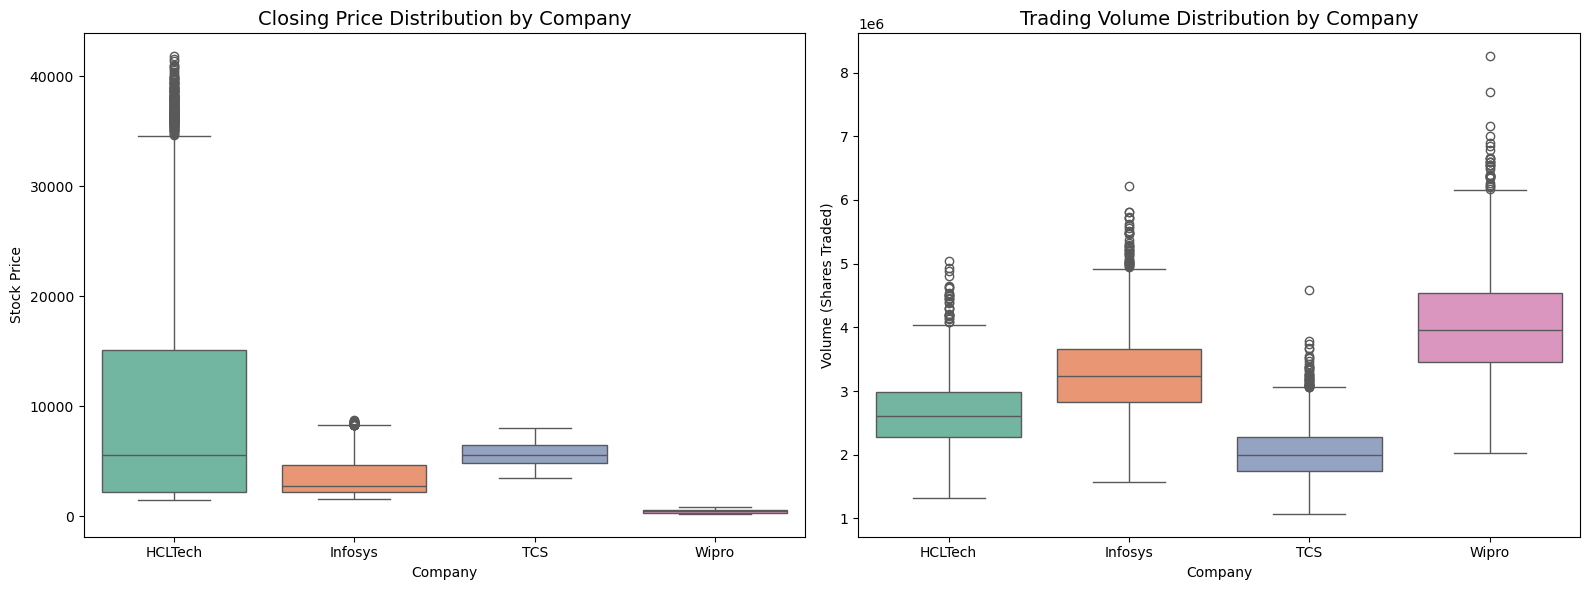

In [12]:
# boxplot by company

import matplotlib.pyplot as plt
import seaborn as sns

# Set up a plotting area with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot for Closing Prices by Company
sns.boxplot(data=df, x='Company', y='Close', ax=axes[0], palette='Set2')
axes[0].set_title('Closing Price Distribution by Company', fontsize=14)
axes[0].set_ylabel('Stock Price')
axes[0].set_xlabel('Company')

# 2. Boxplot for Volume by Company
sns.boxplot(data=df, x='Company', y='Volume', ax=axes[1], palette='Set2')
axes[1].set_title('Trading Volume Distribution by Company', fontsize=14)
axes[1].set_ylabel('Volume (Shares Traded)')
axes[1].set_xlabel('Company')

# Optimize layout and display
plt.tight_layout()
plt.show()
